# Etapa 3 - Seleção de Features (Mutual Information)

Técnica única: Mutual Information (`mutual_info_classif` / `mutual_info_regression`),
calculada no conjunto de treino. Captura relações não lineares (coerente com a MLP),
lida com variáveis binárias/ordinais/contínuas e tem variante para classificação e regressão.

Lógica em `src/feature_selection.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import pandas as pd
from IPython.display import Image, Markdown

import config
from src import feature_selection as fs, preprocessing as pp

config.set_seeds()

C:\Users\Tobias Viero\AppData\Local\Temp\ipykernel_9724\2234636013.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Ranking de MI (cálculo ao vivo, rápido)

Para a tarefa binária. Troque `task` por `"multiclass"` ou `"regression"`.

In [2]:
task = "binary"
data = pp.prepare_data(task)
ranking = fs.compute_mi_ranking(data)
ranking

,feature,mi,mi_normalizada,mi_acumulada
0,GenHlth,0.045372,0.180381,0.180381
1,HighBP,0.034325,0.136463,0.316844
2,BMI,0.031272,0.124325,0.441170
3,HighChol,0.021952,0.087274,0.528443
4,Age,0.020238,0.080459,0.608902
5,DiffWalk,0.019221,0.076416,0.685317
6,Income,0.016909,0.067224,0.752542
7,PhysHlth,0.016523,0.065690,0.818232
8,HeartDiseaseorAttack,0.011587,0.046064,0.864296
9,Education,0.007700,0.030611,0.894907


## 2. Critério de corte e features selecionadas

Mantém as top-k features cuja MI acumulada atinge 90% da MI total.

In [3]:
selected, info = fs.select_features(ranking)
print(f"Inicial: {info['n_inicial']} | Selecionadas: {info['n_selecionado']} | Descartadas: {info['n_descartado']}")
print("Critério:", info["criterio"])
print("Selecionadas:", selected)

Inicial: 21 | Selecionadas: 11 | Descartadas: 10
Critério: MI acumulada >= 90% da MI total
Selecionadas: ['GenHlth', 'HighBP', 'BMI', 'HighChol', 'Age', 'DiffWalk', 'Income', 'PhysHlth', 'HeartDiseaseorAttack', 'Education', 'PhysActivity']


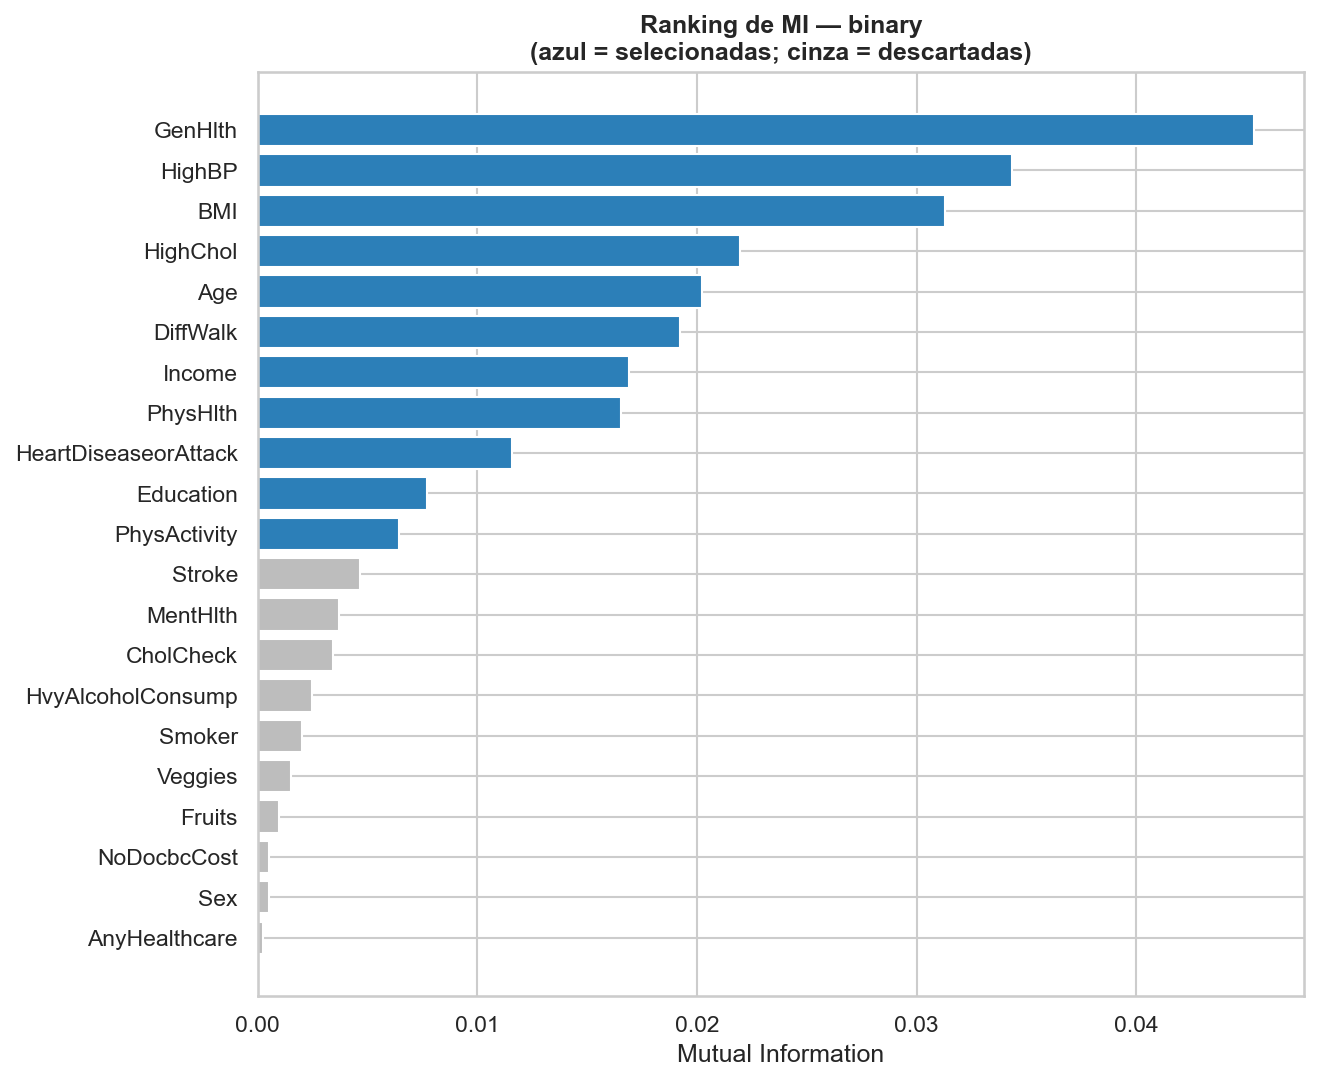

In [4]:
fs.plot_mi_ranking(ranking, task, info["n_selecionado"])
Image(str(config.FIGURES_DIR / f"etapa3_mi_ranking_{task}.png"))

## 3. Rankings salvos das três tarefas

In [5]:
for t in ("binary", "multiclass", "regression"):
    sel = json.load(open(config.METRICS_DIR / f"selected_features_{t}.json", encoding="utf-8"))
    print(f"{t:11s} -> {sel['n_inicial']}->{sel['n_selecionado']} | {sel['selecionadas']}")

binary      -> 21->11 | ['GenHlth', 'HighBP', 'BMI', 'HighChol', 'Age', 'DiffWalk', 'Income', 'PhysHlth', 'HeartDiseaseorAttack', 'Education', 'PhysActivity']
multiclass  -> 21->11 | ['GenHlth', 'HighBP', 'BMI', 'Age', 'DiffWalk', 'HighChol', 'Income', 'PhysHlth', 'HeartDiseaseorAttack', 'Education', 'PhysActivity']
regression  -> 21->12 | ['GenHlth', 'HighBP', 'Diabetes_binary', 'DiffWalk', 'Sex', 'PhysActivity', 'Age', 'PhysHlth', 'Education', 'Income', 'MentHlth', 'HighChol']


## 4. Comparação todas × selecionadas

Treina a MLP baseline (mesma arquitetura/seed) com todas as features e só com as
selecionadas, comparando métrica, gap treino-val e tempo de treino.

Os resultados já estão salvos em `outputs/metrics/feature_selection_comparison.csv`.
Para recomputar (leva alguns minutos), descomente a última linha.

In [7]:
# Recomputar tudo (≈6 min em CPU):
# fs.run(tasks=("binary", "multiclass", "regression"), do_comparison=True)

comparison = pd.read_csv(config.METRICS_DIR / "feature_selection_comparison.csv")
comparison

,tarefa,conjunto,n_features,metrica_treino,metrica_val,metrica_teste,gap_treino_val,tempo_treino_s,epocas
0,binary,todas,21,0.8358,0.8277,0.8262,0.0081,29.59,31
1,binary,selecionadas,11,0.8290,0.8229,0.8215,0.0061,24.43,26
2,multiclass,todas,21,0.4280,0.4236,0.4235,0.0044,22.84,25
3,multiclass,selecionadas,11,0.4244,0.4194,0.4181,0.0050,37.84,34
4,regression,todas,21,0.1811,0.1801,0.1736,0.0009,95.26,76
5,regression,selecionadas,12,0.1745,0.1734,0.1663,0.0011,125.81,100


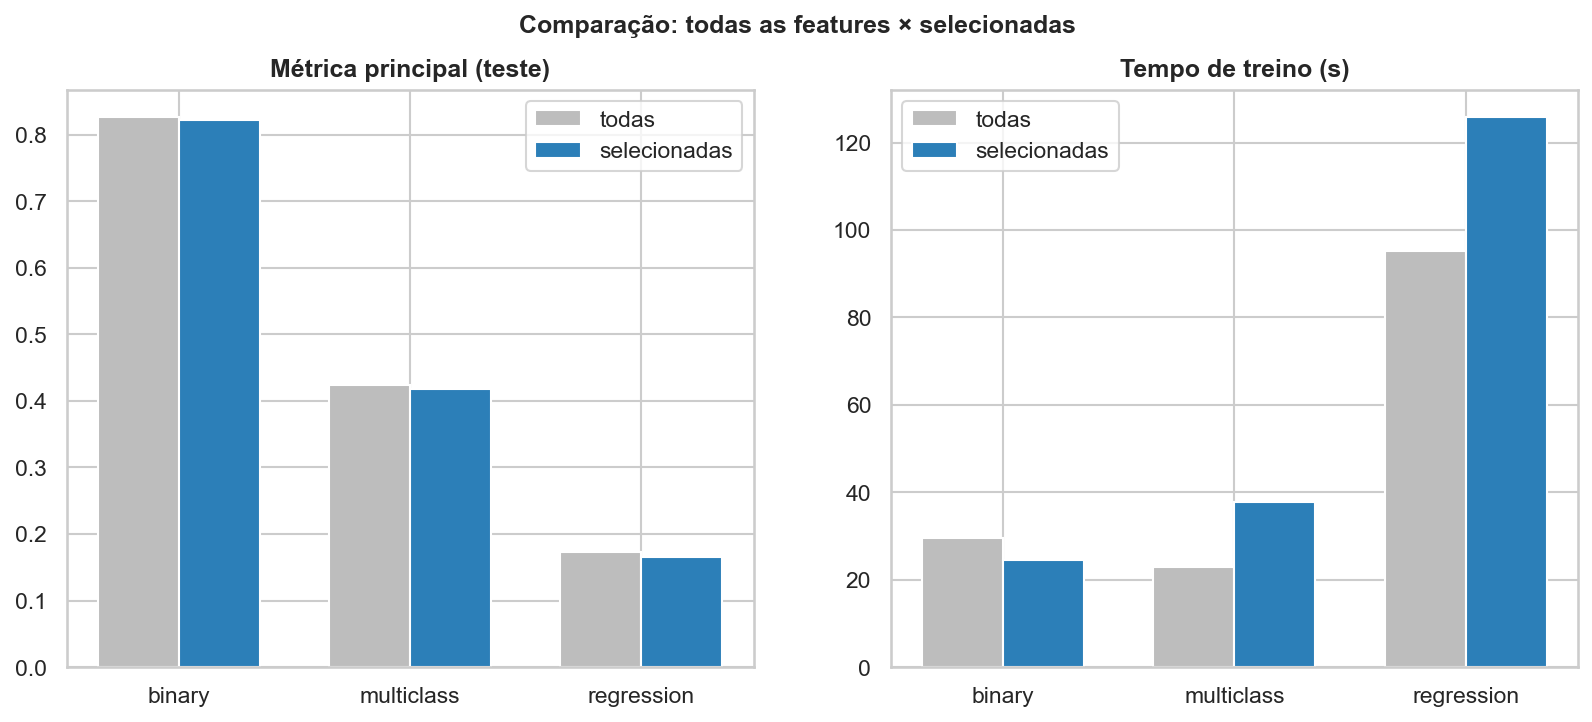

In [8]:
Image(str(config.FIGURES_DIR / "etapa3_fs_comparison.png"))